<!-- AI-og-helse: colab-kontrakt v1 -->

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/AI-og-helse/blob/main/uke07-velferdsteknologi/02_sensorer_aktivitet_og_hendelsesforståelse.ipynb)

## Colab-kjøring

- **Anbefalt runtime:** CPU
- **Forventet kjøretid:** 10-25 min
- **Datamønster:** `synthetic-or-inline`

**Krav før kjøring:**
- API: ikke nødvendig
- Data: syntetisk/simulert data
- GPU: ikke nødvendig

**Felles konvensjon:** Kjør setup-cellen rett under først. Notebooken er selvstendig og bruker bare syntetiske/simulerte data, så API-nøkler og eksterne datafiler er ikke nødvendig.

Kjør cellene ovenfra og ned. Setup-cellen installerer bare ekstra pakker når notebooken åpnes i Colab.

In [1]:
# AI-og-helse: Colab bootstrap v1
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
NOTEBOOK_PACKAGES = []
COLAB_DATA_MODE = 'synthetic-or-inline'


def _has_import(import_name: str) -> bool:
    return importlib.util.find_spec(import_name) is not None


def ensure_packages(packages=NOTEBOOK_PACKAGES):
    """Install only notebook-specific packages when running in Colab."""
    if not IN_COLAB:
        return

    missing = [package for package, import_name in packages if not _has_import(import_name)]
    if missing:
        print("Installerer Colab-pakker:", ", ".join(missing))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    else:
        print("Alle notebook-spesifikke Colab-pakker er tilgjengelige.")


def get_secret(name: str, *aliases: str):
    """Read secrets from environment/.env locally or Colab Secrets in Colab."""
    for key in (name, *aliases):
        value = os.getenv(key)
        if value:
            os.environ[name] = value
            return value

    if IN_COLAB:
        try:
            from google.colab import userdata
        except Exception:
            userdata = None

        if userdata is not None:
            for key in (name, *aliases):
                try:
                    value = userdata.get(key)
                except Exception:
                    value = None
                if value:
                    os.environ[name] = value
                    return value

    return None


def mount_drive_if_needed():
    """Mount Google Drive explicitly in notebooks that need persistent artifacts."""
    if not IN_COLAB:
        return None
    from google.colab import drive

    drive.mount("/content/drive")
    return Path("/content/drive/MyDrive")


ensure_packages()
print("Miljø:", "Google Colab" if IN_COLAB else "lokalt")
print("Datamønster:", COLAB_DATA_MODE)


Miljø: lokalt
Datamønster: synthetic-or-inline


# 🏠 Sensorer, aktivitet og hendelsesforståelse

I forrige notebook så vi på hvordan et teknologisk system kan orientere seg og bevege seg i et miljø. I denne notebooken flytter vi oppmerksomheten fra bevegelse i rommet til tolkning av hverdagslige signaler: Hva kan sensorer fortelle oss om aktivitet, rutiner og mulige avvik i et hjemmemiljø?

Dette er en sentral del av velferdsteknologi fordi mange systemer ikke først og fremst handler om robotikk, men om å registrere hendelser og forsøke å forstå hva de kan bety. Dermed blir overgangen naturlig fra navigasjon til observasjon: Før et system kan støtte mennesker, må det kunne tolke noe om situasjonen.

## Bro fra uke 06

Uke 06 viste at beslutningsstøtte krever validering, terskler, monitorering og tydelig menneskelig ansvar. For sensorer i hjem og omsorg gjelder det samme, men konteksten er annerledes: dataene er mer hverdagslige, situasjonen er ofte ufullstendig, og feil kan vise seg som falske alarmer, manglende varsler eller opplevd overvåking. Derfor må vi skille mellom en enkel sensordemo og en faktisk tjeneste som påvirker brukerens hverdag.

## Læringsmål
- forstå hvordan sensordata kan brukes til å tolke aktivitet og avvik
- skille mellom rå observasjoner og fortolkning
- diskutere styrker og svakheter ved enkle AI- og regelbaserte systemer
- knytte dette til hjemmemonitorering og velferdsteknologi

### 🔧 Miljøoppsett – fungerer både lokalt og i Google Colab

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebooken er selvstendig: den bruker syntetiske sensordata, ingen eksterne filer eller API-nøkler.
IN_COLAB = 'google.colab' in sys.modules
print("🚀 Kjører i Google Colab" if IN_COLAB else "💻 Kjører i lokalt miljø")

# Vi setter seed for å gjøre det syntetiske eksempelet reproduserbart.
# Det betyr at notebooken gir samme resultat hver gang den kjøres.
np.random.seed(42)

# Standard figurstørrelse gjør visualiseringene lettere å lese.
plt.rcParams['figure.figsize'] = (10, 4)

print("✅ Miljø klart")

💻 Kjører i lokalt miljø
✅ Miljø klart


## Fra sensor til tolkning

Velferdsteknologi handler ofte ikke om én stor modell, men om å kombinere mange små signaler:

- bevegelse i rom
- åpning av dør
- tid i seng
- fravær av aktivitet

Utfordringen er at sensoren bare registrerer **hendelser**, ikke hele situasjonen. Vi må derfor tolke mønstre før vi kan si noe om aktivitet, trygghet eller avvik.

In [3]:
# Vi lager en syntetisk hendelseslogg fra et hjemmemiljø over ett døgn.
# Hensikten er å illustrere hvordan flere sensorer kan gi et samlet bilde av aktivitet,
# uten at vi trenger å bruke ekte, sensitive data fra hjemmeoppfølging.

timer = np.arange(24)

# 'bevegelse' kan tolkes som et enkelt aktivitetsnivå per time,
# for eksempel basert på registreringer fra bevegelsessensorer i boligen.
bevegelse = np.array([1, 1, 1, 1, 1, 2, 5, 8, 10, 7, 5, 4, 4, 3, 3, 4, 5, 7, 8, 6, 4, 3, 2, 1])

# 'dør' markerer om ytterdør eller en sentral dør ble åpnet i den aktuelle timen.
# Dette kan være relevant når man ønsker å forstå mobilitet, besøk eller uvanlige hendelser.
dør = np.array([0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0])

# 'seng' er en forenklet indikator på om personen antas å være i seng.
# I praksis kunne dette vært avledet fra trykksensor, madrassensor eller lignende teknologi.
seng = np.array([1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1])

# Vi samler de ulike sensorsignalene i en tabell.
# Det gjør det lettere å utforske mønstre og bygge enkle regler senere i notebooken.
df = pd.DataFrame({
    'time': timer,
    'bevegelse': bevegelse,
    'dør_åpnet': dør,
    'i_seng': seng
})

# Vi viser de første radene for å få et raskt overblikk over datastrukturen.
df.head()

,time,bevegelse,dør_åpnet,i_seng
0,0,1,0,1
1,1,1,0,1
2,2,1,0,1
3,3,1,0,1
4,4,1,0,1


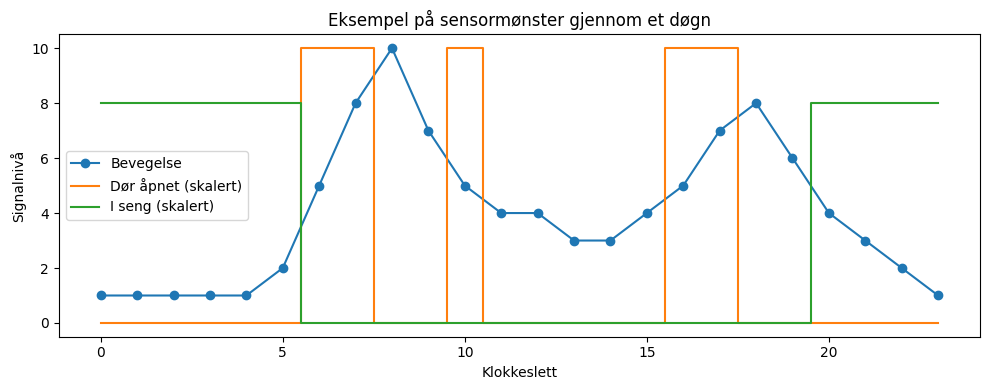

In [4]:
# Her visualiserer vi hvordan flere sensorsignaler varierer gjennom døgnet.
# Målet er å se om det finnes mønstre som kan tolkes som normal aktivitet,
# hvile, forflytning eller mulige avvik.

# Bevegelsessignalet tegnes som en vanlig linje fordi det kan forstås som et aktivitetsnivå.
plt.plot(df['time'], df['bevegelse'], label='Bevegelse', marker='o')

# Dør- og sengesignalene er binære (0 eller 1).
# Derfor bruker vi step-plot for å få tydelige hopp mellom av og på.
# Signalene skaleres bare for å bli synlige i samme figur som bevegelse.
plt.step(df['time'], df['dør_åpnet'] * 10, label='Dør åpnet (skalert)', where='mid')
plt.step(df['time'], df['i_seng'] * 8, label='I seng (skalert)', where='mid')

# Aksene og tittelen gjør det lettere å lese figuren som et døgnforløp.
plt.xlabel('Klokkeslett')
plt.ylabel('Signalnivå')
plt.title('Eksempel på sensormønster gjennom et døgn')
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# Her lager vi en svært enkel, regelbasert metode for å lete etter mulige avvik.
# Poenget er ikke å lage et ferdig klinisk system, men å vise hvordan man kan gå
# fra rå sensorsignaler til en første tolkning av om noe virker uvanlig.

def finn_mulige_avvik(tabell):
    avvik = []

    # Vi går rad for rad gjennom tabellen og ser etter mønstre vi på forhånd har definert som interessante.
    for _, rad in tabell.iterrows():
        # I dette eksempelet tolker vi null bevegelse midt på dagen som et mulig avvik.
        # En slik regel kan være relevant dersom personen vanligvis er aktiv i dette tidsrommet.
        if rad['time'] in [10, 11, 12, 13, 14] and rad['bevegelse'] == 0:
            avvik.append((int(rad['time']), 'Uvanlig lite aktivitet midt på dagen'))

    return avvik

# Vi bruker funksjonen på det syntetiske datasettet.
avvik = finn_mulige_avvik(df)
print('Mulige avvik:')

# Resultatet skrives ut i lesbar tekstform.
# Dette illustrerer hvordan et enkelt system kan flagge hendelser for videre vurdering.
if avvik:
    for tidspunkt, tekst in avvik:
        print(f'- kl. {tidspunkt}: {tekst}')
else:
    print('- ingen avvik funnet i dette enkle eksemplet')

Mulige avvik:
- ingen avvik funnet i dette enkle eksemplet


### Refleksjon
- Hvilke begrensninger ser du ved å tolke aktivitet bare fra enkle sensorer?
- Hva er forskjellen mellom lav aktivitet og et faktisk problem?
- Når kan slike systemer gi nyttig støtte, og når kan de skape unødige alarmer?
- Hvem bør få varselet, og hva skal de faktisk gjøre med det?
- Hvordan kan systemet monitoreres slik at falske alarmer og manglende varsler oppdages over tid?

## Oppsummering

Denne notebooken viser hvordan enkle, syntetiske sensorsignaler kan brukes til å utforske aktivitet, rutiner og mulige avvik i et hjemmemiljø. Hovedpoenget er at sensordata alltid må tolkes i kontekst, og at et signal alene sjelden er nok til å konkludere.

Videre i uke 07 går vi fra tolkning av sensorsignaler til beslutningsstøtte: hvordan slike observasjoner kan brukes til varsler, prioritering og oppfølging i hjem og omsorg.